In [71]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Dense
# from keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img
from keras.optimizers import RMSprop

import numpy as np
import matplotlib.pyplot as plt


In [60]:
train_data = tf.keras.utils.image_dataset_from_directory("/mnt/d/piicture/dataset_cat_dog/train",
                                                         image_size=(150, 150),
                                                         batch_size=32,
                                                         label_mode="binary",
                                                         shuffle=True
                                                         )

val_data = tf.keras.utils.image_dataset_from_directory("/mnt/d/piicture/dataset_cat_dog/val", 
                                                       image_size=(150, 150),
                                                       batch_size=32)

Found 2 files belonging to 2 classes.


Found 2 files belonging to 2 classes.


In [61]:
images, labels = next(iter(train_data))

In [62]:
images.shape

TensorShape([2, 150, 150, 3])

In [63]:
labels.shape

TensorShape([2, 1])

In [64]:
print(labels[1])

tf.Tensor([0.], shape=(1,), dtype=float32)


Text(0.5, 1.0, '[1.]')

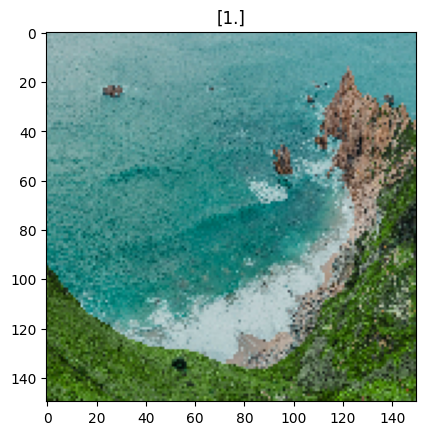

In [65]:
plt.imshow(images[0].numpy().astype(np.uint8)); plt.title(labels[0].numpy())

In [66]:
model_aug = Sequential()

model_aug.add(layers.RandomRotation(0.1))
model_aug.add(layers.RandomFlip())
model_aug.add(layers.RandomShear(0.1))

In [ ]:
input = layers.Input((150, 150, 3))
x = model_aug(input, training = True)

x = Conv2D(32, (3, 3), activation='relu')(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPool2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPool2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPool2D((2, 2))(x)

x = Flatten()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(1, activation='sigmoid')(x)

Model_cnn = keras.Model(input, x)

In [76]:
Model_cnn.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
Model_cnn.compile(optimizer=RMSprop(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [74]:
history = Model_cnn.fit(x=train_data, 
                        epochs=10,
                        validation_data=val_data
                        )

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 15.7838 - val_accuracy: 0.5000 - val_loss: 6.2577
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 5.9438 - val_accuracy: 0.5000 - val_loss: 0.7173
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.8325 - val_accuracy: 1.0000 - val_loss: 0.1318
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 1.8169e-09
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 5.2506e-05 - val_accuracy: 1.0000 - val_loss: 2.1492e-09
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 7.0113e-08 - val_accuracy: 1.0000 - val_loss: 2.1496e-09
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 2.0764e-09 - val_accuracy: 1.0000 - val_loss: 2.1497e-09
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 3.0461e-06 - val_accuracy: 1.0000 - 